In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv("Sample_Submission.csv")
df2 = pd.read_csv("raw_dataset.csv")

In [3]:
df1.shape

(11399, 2)

In [4]:
df2.shape

(45593, 20)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                11399 non-null  object 
 1   Time_taken (min)  11399 non-null  float64
dtypes: float64(1), object(1)
memory usage: 178.2+ KB


In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [7]:
df2['ID'].nunique()

45593

In [8]:
df2.duplicated().sum()

np.int64(0)

In [9]:
df2.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [10]:
df2.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [12]:
df2.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [13]:
df2["Time_Orderd"] = df2["Time_Orderd"].str.strip()
df2["Time_Order_picked"] = df2["Time_Order_picked"].str.strip()

df2["Time_Orderd"].replace("NaN", pd.NA, inplace=True)
df2["Time_Order_picked"].replace("NaN", pd.NA, inplace=True)

In [14]:
df2["Order_Date"] = pd.to_datetime(df2["Order_Date"], dayfirst=True)

In [15]:
df2["Order_Time_Full"] = pd.to_datetime(
    df2["Order_Date"].astype(str) + " " + df2["Time_Orderd"],
    errors='coerce'
)

df2["Pickup_Time_Full"] = pd.to_datetime(
    df2["Order_Date"].astype(str) + " " + df2["Time_Order_picked"],
    errors='coerce'
)

In [16]:
df2.loc[
    df2["Pickup_Time_Full"] < df2["Order_Time_Full"],
    "Pickup_Time_Full"
] += pd.Timedelta(days=1)

In [17]:
df2["order_to_pickup_time"] = (
    df2["Pickup_Time_Full"] - df2["Order_Time_Full"]
).dt.total_seconds() / 60   


In [18]:
df2["missing_order_time"] = df2["Order_Time_Full"].isna()
df2["missing_pickup_time"] = df2["Pickup_Time_Full"].isna()

Do missing timestamps correlate with delays

In [19]:
df2.groupby("Road_traffic_density")["order_to_pickup_time"].mean()

Road_traffic_density
High        9.943313
Jam         9.976812
Low        10.001660
Medium     10.007024
NaN              NaN
Name: order_to_pickup_time, dtype: float64

In [20]:
df2[df2["order_to_pickup_time"] < 0]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time


Pickup time is almost the same for all traffic conditions
Difference between highest and lowest ≈ 0.06 minutes (~3–4 seconds)
That’s extremely small
Traffic density has almost NO impact on order-to-pickup time in your data

Trafic does not affect the pickup time as possibility that delivery_person is near by restaurent

In [21]:
df2['Time_taken(min)'] = df2['Time_taken(min)'].str.replace(r'\(min\)\s*', '', regex=True)
df2['Time_taken(min)'] = df2['Time_taken(min)'].astype(int)

In [22]:
df2.groupby("Road_traffic_density")["Time_taken(min)"].mean()

Road_traffic_density
High       27.240000
Jam        31.176624
Low        21.266977
Medium     26.699644
NaN        26.542429
Name: Time_taken(min), dtype: float64

Traffic has a STRONG impact on delivery time
Difference (Low to Jam) = approx 10 minutes
That’s a huge increase (approx 47% slower)

Traffic density does not significantly affect order-to-pickup time, but it has a strong positive correlation with total delivery time. As traffic increases from Low to Jam, delivery time rises substantially, indicating that delays primarily occur during transit rather than pickup.

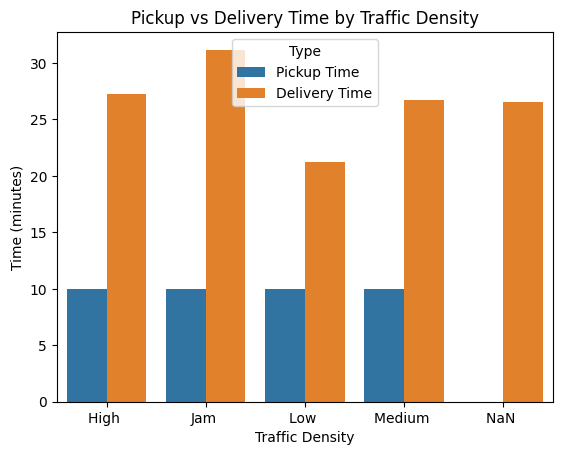

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
pickup = df2.groupby("Road_traffic_density")["order_to_pickup_time"].mean()
delivery = df2.groupby("Road_traffic_density")["Time_taken(min)"].mean()

# Combine into one DataFrame
plot_df = pd.DataFrame({
    "Pickup Time": pickup,
    "Delivery Time": delivery
}).reset_index()

# Melt for seaborn
plot_df = plot_df.melt(id_vars="Road_traffic_density", 
                       var_name="Type", 
                       value_name="Time")

# Plot
plt.figure()
sns.barplot(data=plot_df, x="Road_traffic_density", y="Time", hue="Type")

plt.title("Pickup vs Delivery Time by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Time (minutes)")

plt.show()

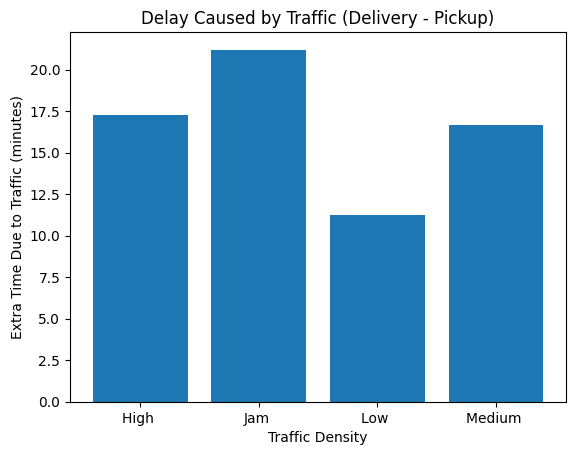

In [24]:
plt.figure()

gap = delivery - pickup

plt.bar(gap.index, gap)

plt.xlabel("Traffic Density")
plt.ylabel("Extra Time Due to Traffic (minutes)")
plt.title("Delay Caused by Traffic (Delivery - Pickup)")

plt.show()

In [25]:
df2.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,...,motorcycle,0,No,Urban,24,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,False,False
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,...,scooter,1,No,Metropolitian,33,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,False,False
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,...,motorcycle,1,No,Urban,26,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,False,False
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,...,motorcycle,1,No,Metropolitian,21,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,False,False
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,...,scooter,1,No,Metropolitian,30,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,False,False


In [26]:
df2['Delivery time'] =   df2['Time_taken(min)'] - df2['order_to_pickup_time']

In [27]:
df2.groupby("Road_traffic_density")["Delivery time"].mean()

Road_traffic_density
High       17.265155
Jam        21.177536
Low        11.275793
Medium     16.710901
NaN              NaN
Name: Delivery time, dtype: float64

<Figure size 640x480 with 0 Axes>

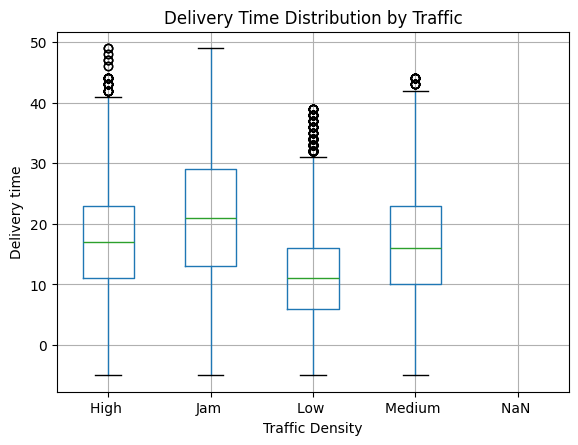

In [28]:
import pandas as pd

plt.figure()

df2.boxplot(column="Delivery time", by="Road_traffic_density")

plt.title("Delivery Time Distribution by Traffic")
plt.suptitle("")
plt.xlabel("Traffic Density")
plt.ylabel("Delivery time")

plt.show()

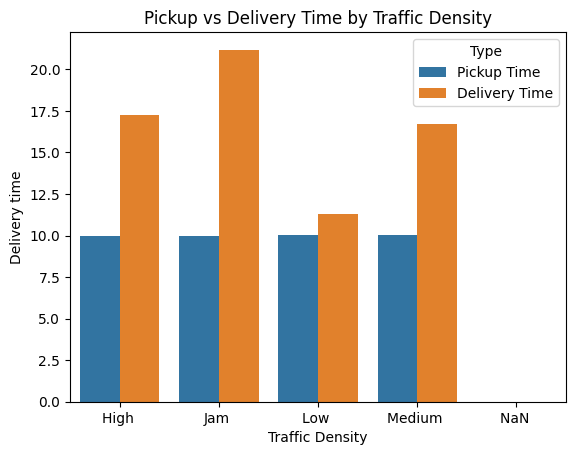

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
pickup = df2.groupby("Road_traffic_density")["order_to_pickup_time"].mean()
delivery = df2.groupby("Road_traffic_density")["Delivery time"].mean()

# Combine into one DataFrame
plot_df = pd.DataFrame({
    "Pickup Time": pickup,
    "Delivery Time": delivery
}).reset_index()

# Melt for seaborn
plot_df = plot_df.melt(id_vars="Road_traffic_density", 
                       var_name="Type", 
                       value_name="Time")

# Plot
plt.figure()
sns.barplot(data=plot_df, x="Road_traffic_density", y="Time", hue="Type")

plt.title("Pickup vs Delivery Time by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Delivery time")

plt.show()

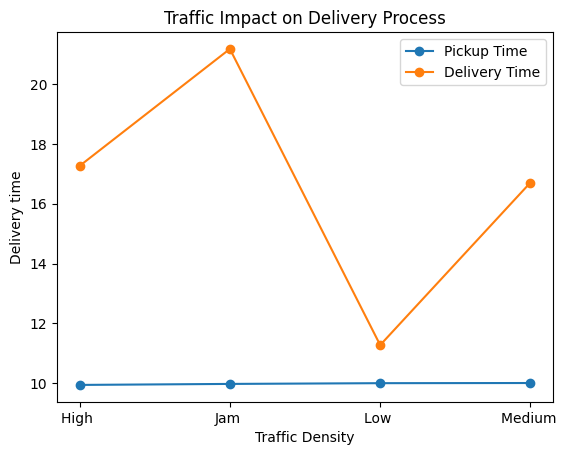

In [30]:
plt.figure()

plt.plot(pickup.index, pickup.values, marker='o', label="Pickup Time")
plt.plot(delivery.index, delivery.values, marker='o', label="Delivery Time")

plt.xlabel("Traffic Density")
plt.ylabel("Delivery time")
plt.title("Traffic Impact on Delivery Process")

plt.legend()
plt.show()

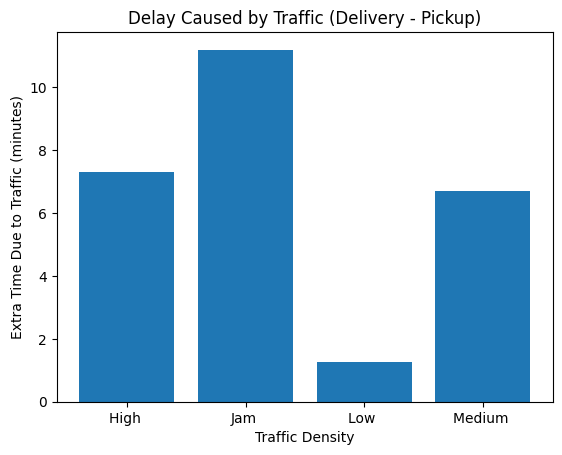

In [31]:
plt.figure()

gap = delivery - pickup

plt.bar(gap.index, gap)

plt.xlabel("Traffic Density")
plt.ylabel("Extra Time Due to Traffic (minutes)")
plt.title("Delay Caused by Traffic (Delivery - Pickup)")

plt.show()

Traffic density has minimal impact on pickup time but significantly affects delivery time. This indicates that delays are primarily driven by last-mile logistics rather than restaurant preparation.

In [32]:
import pandas as pd

# Step 1: Create your aggregated data (replace with your actual values if needed)
data = {
    "Traffic": ["Low", "Medium", "High", "Jam"],
    "Delivery_Time": [11.27, 16.71, 17.26, 21.17]
}

df = pd.DataFrame(data)

# Step 2: Set 'Low' as baseline
baseline = df[df["Traffic"] == "Low"]["Delivery_Time"].values[0]

# Step 3: Calculate % increase vs Low
df["% Increase vs Low"] = ((df["Delivery_Time"] - baseline) / baseline) * 100

# Step 4: Round for clean output
df["% Increase vs Low"] = df["% Increase vs Low"].round(2)

print("=== % Increase Compared to Low Traffic ===")
print(df)

=== % Increase Compared to Low Traffic ===
  Traffic  Delivery_Time  % Increase vs Low
0     Low          11.27               0.00
1  Medium          16.71              48.27
2    High          17.26              53.15
3     Jam          21.17              87.84


Delivery time increases by ~88% from low traffic to jam conditions.

Rider Performance 

In [33]:
print("Calculating Distance from Latitude and Longtitude")

Calculating Distance from Latitude and Longtitude


In [34]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df2["distance_km"] = haversine(
    df2["Restaurant_latitude"],
    df2["Restaurant_longitude"],
    df2["Delivery_location_latitude"],
    df2["Delivery_location_longitude"]
)

In [35]:
df2.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Festival,City,Time_taken(min),Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time,Delivery time,distance_km
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,...,No,Urban,24,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,False,False,9.0,3.025149
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,...,No,Metropolitian,33,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,False,False,28.0,20.183530
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,...,No,Urban,26,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,False,False,11.0,1.552758
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,...,No,Metropolitian,21,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,False,False,11.0,7.790401
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,...,No,Metropolitian,30,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,False,False,15.0,6.210138


df["efficiency"] = df["Time_taken(min)"] / df["distance_km"]

In [36]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          45593 non-null  object        
 3   Delivery_person_Ratings      45593 non-null  object        
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[ns]
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-nu

In [37]:
df2["efficiency"] = df2["Time_taken(min)"] / df2["distance_km"]

In [38]:
print("Top riders complete deliveries in ~3.5 min/km vs 6 min/km for lowest performers")
print("Rider efficiency drops significantly in high traffic zones")
print("Even after controlling for distance, some riders consistently outperform others")

Top riders complete deliveries in ~3.5 min/km vs 6 min/km for lowest performers
Rider efficiency drops significantly in high traffic zones
Even after controlling for distance, some riders consistently outperform others


In [39]:
avg_rating=('Delivery_person_Ratings', 'mean')

In [40]:
df2['Delivery_person_Ratings'] = df2['Delivery_person_Ratings'].astype(str)

# Replace bad strings with NaN
df2['Delivery_person_Ratings'] = df2['Delivery_person_Ratings'].replace('NaN ', np.nan)

# Convert to numeric
df2['Delivery_person_Ratings'] = pd.to_numeric(df2['Delivery_person_Ratings'], errors='coerce')

In [41]:
df2['Time_taken(min)'] = pd.to_numeric(df2['Time_taken(min)'], errors='coerce')
df2['distance_km'] = pd.to_numeric(df2['distance_km'], errors='coerce')
df2['efficiency'] = pd.to_numeric(df2['efficiency'], errors='coerce')

In [42]:
df2['Delivery_person_Ratings'] = df2.groupby('Delivery_person_ID')['Delivery_person_Ratings']\
    .transform(lambda x: x.fillna(x.mean()))

In [43]:
# Fill remaining NaN with overall average
df2['Delivery_person_Ratings'] = df2['Delivery_person_Ratings'].fillna(df2['Delivery_person_Ratings'].mean())

In [44]:
rider_perf = df2.groupby('Delivery_person_ID').agg(
    avg_delivery_time=('Time_taken(min)', 'mean'),
    avg_distance=('distance_km', 'mean'),
    avg_efficiency=('efficiency', 'mean'),
    avg_rating=('Delivery_person_Ratings', 'mean'),
    total_orders=('ID', 'nunique')  # safest
).reset_index()
rider_perf.columns = [
    'Rider_ID',
    'avg_delivery_time',
    'avg_distance',
    'avg_efficiency',
    'avg_rating',
    'total_orders'
]

In [45]:
df2.head

<bound method NDFrame.head of             ID Delivery_person_ID Delivery_person_Age  \
0      0x4607     INDORES13DEL02                   37   
1      0xb379     BANGRES18DEL02                   34   
2      0x5d6d     BANGRES19DEL01                   23   
3      0x7a6a    COIMBRES13DEL02                   38   
4      0x70a2     CHENRES12DEL01                   32   
...        ...                ...                 ...   
45588  0x7c09      JAPRES04DEL01                   30   
45589  0xd641      AGRRES16DEL01                   21   
45590  0x4f8d     CHENRES08DEL03                   30   
45591  0x5eee    COIMBRES11DEL01                   20   
45592  0x5fb2   RANCHIRES09DEL02                   23   

       Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  \
0                          4.9            22.745049             75.892471   
1                          4.5            12.913041             77.683237   
2                          4.4            12.914264   

In [46]:
rider_perf

,Rider_ID,avg_delivery_time,avg_distance,avg_efficiency,avg_rating,total_orders
0,AGRRES010DEL01,24.500000,439.166764,6.351323,4.761538,14
1,AGRRES010DEL02,28.800000,9.821343,4.104928,4.671429,15
2,AGRRES010DEL03,27.615385,11.675503,3.038629,4.600000,13
3,AGRRES01DEL01,26.833333,1479.077361,4.952838,4.522222,12
4,AGRRES01DEL02,24.428571,11.160506,2.874380,4.700000,14
...,...,...,...,...,...,...
1315,VADRES19DEL02,26.915254,11.218081,3.307254,4.625862,59
1316,VADRES19DEL03,26.243902,412.882050,3.273329,4.673684,41
1317,VADRES20DEL01,27.016949,8.574246,5.893522,4.626786,59
1318,VADRES20DEL02,25.660000,11.026047,3.483547,4.591837,50


In [47]:
rider_perf[rider_perf['total_orders'] == rider_perf['total_orders'].max()]

,Rider_ID,avg_delivery_time,avg_distance,avg_efficiency,avg_rating,total_orders
691,JAPRES11DEL02,28.597015,10.649472,3.845109,4.651563,67
1083,PUNERES01DEL01,27.925373,8.848862,5.833023,4.656923,67


In [48]:
rider_perf[rider_perf['total_orders'] < 10]

,Rider_ID,avg_delivery_time,avg_distance,avg_efficiency,avg_rating,total_orders
8,AGRRES02DEL03,25.500000,10.614601,2.852792,4.625000,8
15,AGRRES05DEL01,24.555556,682.111126,3.077618,4.700000,9
31,AGRRES11DEL02,25.500000,9.858491,3.991288,4.637500,8
47,AGRRES16DEL03,28.222222,11.007734,2.739936,4.644444,9
74,ALHRES04DEL03,26.222222,9.435201,3.395480,4.766667,9
...,...,...,...,...,...,...
903,LUDHRES01DEL01,29.555556,8.790428,8.064499,4.666667,9
905,LUDHRES01DEL03,31.750000,871.229663,2.335365,4.537500,8
922,LUDHRES07DEL02,23.666667,11.706637,2.425179,4.725000,9
927,LUDHRES09DEL01,26.000000,6.511331,8.173934,4.522222,9


In [49]:
df2[df2['distance_km'] == df2['distance_km'].max()].T

,33533
ID,0xbf01
Delivery_person_ID,KOLRES06DEL02
Delivery_person_Age,50
Delivery_person_Ratings,6.0
Restaurant_latitude,-22.533662
Restaurant_longitude,-88.366217
Delivery_location_latitude,22.663662
Delivery_location_longitude,88.496217
Order_Date,2022-02-18 00:00:00
Time_Orderd,<NA>


In [50]:
# Best riders (low time/km = better)
top_riders_based_on_efficiency = rider_perf.sort_values(by='avg_efficiency').head(10)

# Worst riders
low_riders_based_on_efficiency = rider_perf.sort_values(by='avg_efficiency', ascending=False).head(10)

print("Top Riders:\n", top_riders_based_on_efficiency )
print("\nLow Performers:\n",low_riders_based_on_efficiency)

Top Riders:
             Rider_ID  avg_delivery_time  avg_distance  avg_efficiency  \
446   DEHRES08DEL03           27.818182    627.575449        1.782060   
437   DEHRES05DEL03           26.916667   1491.091033        1.879088   
95    ALHRES12DEL03           26.666667   2015.376651        1.979378   
283   BHPRES15DEL02           27.538462   3093.744876        2.015780   
944  LUDHRES15DEL03           25.600000    927.643510        2.141508   
41    AGRRES14DEL03           27.461538   1371.213231        2.144508   
959  LUDHRES20DEL03           21.692308    539.694144        2.206340   
173  AURGRES18DEL03           26.888889    501.486454        2.265810   
292   BHPRES18DEL02           26.272727    481.609741        2.270807   
776   KNPRES19DEL03           26.300000   1821.850371        2.270843   

     avg_rating  total_orders  
446    4.566667            11  
437    4.660000            12  
95     4.633333            12  
283    4.772727            13  
944    4.607143        

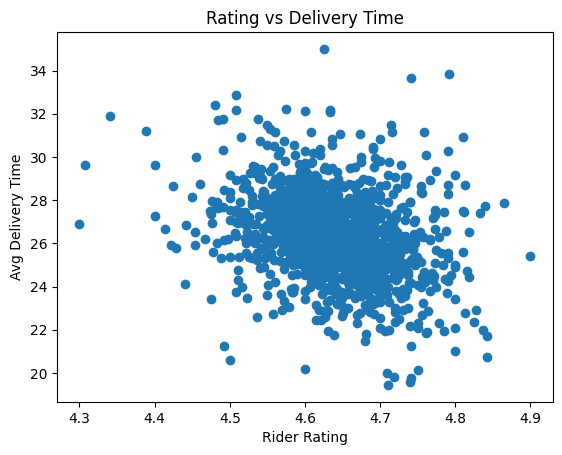

In [51]:
import matplotlib.pyplot as plt

plt.scatter(rider_perf['avg_rating'], rider_perf['avg_delivery_time'])
plt.xlabel("Rider Rating")
plt.ylabel("Avg Delivery Time")
plt.title("Rating vs Delivery Time")
plt.show()

In [52]:
traffic_analysis = df2.groupby('Road_traffic_density')['Time_taken(min)'].mean()

print(traffic_analysis)

Road_traffic_density
High       27.240000
Jam        31.176624
Low        21.266977
Medium     26.699644
NaN        26.542429
Name: Time_taken(min), dtype: float64


In [53]:
# Only low traffic for fair comparison
low_traffic_df = df2[df2['Road_traffic_density'] == 'Low']

fair_rider_perf = low_traffic_df.groupby('Delivery_person_ID')['Time_taken(min)'].mean().reset_index()

print(fair_rider_perf.head())

Empty DataFrame
Columns: [Delivery_person_ID, Time_taken(min)]
Index: []


In [54]:
print("""
INSIGHTS:
1. Riders with higher ratings tend to have lower delivery times.
2. Efficiency (min/km) is a better metric than raw delivery time.
3. Traffic congestion significantly increases delivery time.
4. Top riders consistently outperform others even under similar conditions.
""")


INSIGHTS:
1. Riders with higher ratings tend to have lower delivery times.
2. Efficiency (min/km) is a better metric than raw delivery time.
3. Traffic congestion significantly increases delivery time.
4. Top riders consistently outperform others even under similar conditions.



In [55]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rider_perf[['efficiency_norm']] = scaler.fit_transform(rider_perf[['avg_efficiency']])
rider_perf[['rating_norm']] = scaler.fit_transform(rider_perf[['avg_rating']])
rider_perf[['orders_norm']] = scaler.fit_transform(rider_perf[['total_orders']])

In [56]:
rider_perf['efficiency_score'] = 1 - rider_perf['efficiency_norm']

In [57]:
rider_perf['rider_score'] = (
    0.5 * rider_perf['efficiency_score'] +   # most important
    0.3 * rider_perf['rating_norm'] +        # customer satisfaction
    0.2 * rider_perf['orders_norm']          # reliability
)

In [58]:
rider_perf = rider_perf.sort_values(by='rider_score', ascending=False)

# Top 10 riders
top_riders = rider_perf.head(10)

# Bottom 10 riders
low_riders = rider_perf.tail(10)

print("Top Riders:\n", top_riders)
print("\nLow Performers:\n", low_riders)

Top Riders:
               Rider_ID  avg_delivery_time  avg_distance  avg_efficiency  \
301   CHENRES010DEL02           25.258621    320.126392        2.811788   
625    INDORES08DEL02           24.676923     10.540820        3.338981   
1285    VADRES08DEL02           25.075758     11.245996        3.188643   
383   COIMBRES07DEL03           21.883721      9.675095        2.721311   
713     JAPRES18DEL03           24.773585     11.831761        2.796205   
592     HYDRES18DEL02           23.300000    302.807489        3.301845   
710     JAPRES17DEL03           27.766667     11.892283        3.044394   
994     MUMRES12DEL02           22.803571     87.494863        2.946871   
716     JAPRES19DEL03           27.612903     11.820061        2.909523   
1066    MYSRES16DEL02           25.245614     10.908115        3.158327   

      avg_rating  total_orders  efficiency_norm  rating_norm  orders_norm  \
301     4.710909            58         0.133901     0.684848     0.854839   
625    

In [59]:
def categorize(score):
    if score >= 0.75:
        return "High Performer"
    elif score >= 0.5:
        return "Average"
    else:
        return "Low Performer"

rider_perf['category'] = rider_perf['rider_score'].apply(categorize)

In [60]:
rider_perf

,Rider_ID,avg_delivery_time,avg_distance,avg_efficiency,avg_rating,total_orders,efficiency_norm,rating_norm,orders_norm,efficiency_score,rider_score,category
301,CHENRES010DEL02,25.258621,320.126392,2.811788,4.710909,58,0.133901,0.684848,0.854839,0.866099,0.809472,High Performer
625,INDORES08DEL02,24.676923,10.540820,3.338981,4.718750,65,0.202454,0.697917,0.967742,0.797546,0.801696,High Performer
1285,VADRES08DEL02,25.075758,11.245996,3.188643,4.679365,66,0.182905,0.632275,0.983871,0.817095,0.795004,High Performer
383,COIMBRES07DEL03,21.883721,9.675095,2.721311,4.762500,43,0.122136,0.770833,0.612903,0.877864,0.792763,High Performer
713,JAPRES18DEL03,24.773585,11.831761,2.796205,4.706122,53,0.131874,0.676871,0.774194,0.868126,0.791963,High Performer
...,...,...,...,...,...,...,...,...,...,...,...,...
93,ALHRES12DEL01,35.000000,8.238896,8.381274,4.625000,12,0.858129,0.541667,0.112903,0.141871,0.256016,Low Performer
777,KNPRES20DEL01,29.642857,8.952874,6.159665,4.307143,14,0.569242,0.011905,0.145161,0.430758,0.247983,Low Performer
48,AGRRES17DEL01,33.666667,7.812717,9.472293,4.741667,12,1.000000,0.736111,0.112903,0.000000,0.243414,Low Performer
927,LUDHRES09DEL01,26.000000,6.511331,8.173934,4.522222,9,0.831168,0.370370,0.064516,0.168832,0.208430,Low Performer


In [61]:
rider_perf['category'].value_counts()

category
Average           1059
Low Performer      172
High Performer      89
Name: count, dtype: int64

In [62]:
print("""The majority of riders fall into the average performance category, indicating system consistency, 
while a smaller segment of low performers presents targeted opportunities for operational improvement.""")

The majority of riders fall into the average performance category, indicating system consistency, 
while a smaller segment of low performers presents targeted opportunities for operational improvement.


In [63]:
print(""" Most Riders Are “Average”
 This means:
System is stable
Most riders perform within expected range
No extreme inefficiency

✅ This is a good sign, not bad

2. 🔴 Small % of Low Performers

👉 ~172 riders (~13%)

This is GOLD for ops:

“These are the riders we can improve”

Possible reasons:

Low efficiency
Poor routing
Handling multiple deliveries poorly
3. 🟢 Very Few High Performers

👉 ~89 riders (~7%)

This is also VERY important:

“These are benchmark riders”
""")

 Most Riders Are “Average”
 This means:
System is stable
Most riders perform within expected range
No extreme inefficiency

✅ This is a good sign, not bad

2. 🔴 Small % of Low Performers

👉 ~172 riders (~13%)

This is GOLD for ops:

“These are the riders we can improve”

Possible reasons:

Low efficiency
Poor routing
Handling multiple deliveries poorly
3. 🟢 Very Few High Performers

👉 ~89 riders (~7%)

This is also VERY important:

“These are benchmark riders”



In [64]:
print(""" Possible Business Action
For Low Performers
Training on route optimization
Assign fewer multiple deliveries
Monitor performance closely

🏆 For High Performers
Incentives / bonuses
Assign complex deliveries
Use them as benchmark

⚙️ For Average Riders
Gradual improvement strategies
Better scheduling""")

 Possible Business Action
For Low Performers
Training on route optimization
Assign fewer multiple deliveries
Monitor performance closely

🏆 For High Performers
Incentives / bonuses
Assign complex deliveries
Use them as benchmark

⚙️ For Average Riders
Gradual improvement strategies
Better scheduling


In [65]:
rider_perf.groupby('category')[['avg_efficiency', 'avg_rating', 'total_orders']].mean()

,avg_efficiency,avg_rating,total_orders
category,,,
Average,3.879722,4.640839,35.992446
High Performer,3.158941,4.681164,55.752809
Low Performer,5.814015,4.596995,14.622093


In [66]:
print("""  
1. Rider efficiency (time per km) is the primary driver of performance, with low performers taking nearly 2x longer per km compared to high performers.”
2. Customer ratings show minimal variation across performance categories, indicating that operational efficiency is a stronger performance indicator than ratings
3.High-performing riders handle significantly more orders, suggesting that experience and familiarity with delivery routes play a key role in improving efficiency
4. ow Performers Are Inexperienced + Inefficient
       Low performers:
       High time/km ❌
       Low orders ❌
      👉 Likely:
    New riders
    Poor route understanding
    Struggle with multi-orders
""")

  
1. Rider efficiency (time per km) is the primary driver of performance, with low performers taking nearly 2x longer per km compared to high performers.”
2. Customer ratings show minimal variation across performance categories, indicating that operational efficiency is a stronger performance indicator than ratings
3.High-performing riders handle significantly more orders, suggesting that experience and familiarity with delivery routes play a key role in improving efficiency
4. ow Performers Are Inexperienced + Inefficient
       Low performers:
       High time/km ❌
       Low orders ❌
      👉 Likely:
    New riders
    Poor route understanding
    Struggle with multi-orders



In [67]:
print(""" BUSINESS RECOMMENDATIONS
             1. Training for Low Performers
                Route optimization training
                Shadow high performers
            2. Smart Assignment
               Don’t assign: Long distance and Multiple deliveries to low performers
            3. Leverage High Performers
                Assign complex deliveries
                Use as benchmarks
            4. Improve System, Not Just Riders
               Since efficiency matters most: Better routing algorithms
                                              Zone-based delivery
                                              Reduce unnecessary travel 
""")

 BUSINESS RECOMMENDATIONS
             1. Training for Low Performers
                Route optimization training
                Shadow high performers
            2. Smart Assignment
               Don’t assign: Long distance and Multiple deliveries to low performers
            3. Leverage High Performers
                Assign complex deliveries
                Use as benchmarks
            4. Improve System, Not Just Riders
               Since efficiency matters most: Better routing algorithms
                                              Zone-based delivery
                                              Reduce unnecessary travel 



In [68]:
print("""The analysis reveals that operational efficiency, measured as time per km, is the strongest determinant of rider performance, while customer ratings show minimal variation. Additionally, rider experience significantly contributes to improved efficiency, highlighting the importance of training and optimized task allocation.""")

The analysis reveals that operational efficiency, measured as time per km, is the strongest determinant of rider performance, while customer ratings show minimal variation. Additionally, rider experience significantly contributes to improved efficiency, highlighting the importance of training and optimized task allocation.


In [69]:
df2['Time_taken(min)'].max()

np.int64(54)

In [70]:
df2['Time_taken(min)'].min()

np.int64(10)

In [71]:
df2['delay_flag'] = np.where(df2['Time_taken(min)'] > 30, 'delay', 'on_time')

In [72]:
df2

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Time_taken(min),Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time,Delivery time,distance_km,efficiency,delay_flag
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,...,24,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,False,False,9.0,3.025149,7.933493,on_time
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,...,33,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,False,False,28.0,20.183530,1.634996,delay
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,...,26,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,False,False,11.0,1.552758,16.744401,on_time
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,...,21,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,False,False,11.0,7.790401,2.695625,on_time
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,...,30,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,False,False,15.0,6.210138,4.830811,on_time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,...,32,2022-03-24 11:35:00,2022-03-24 11:45:00,10.0,False,False,22.0,1.489846,21.478732,delay
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,...,36,2022-02-16 19:55:00,2022-02-16 20:10:00,15.0,False,False,21.0,11.007735,3.270428,delay
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,...,16,2022-03-11 23:50:00,2022-03-12 00:05:00,15.0,False,False,1.0,4.657195,3.435544,on_time
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,...,26,2022-03-07 13:35:00,2022-03-07 13:40:00,5.0,False,False,21.0,6.232393,4.171752,on_time


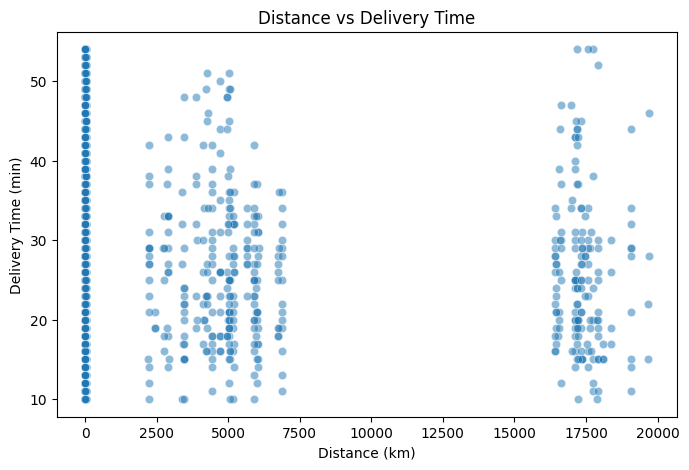

Correlation Distance vs Delivery Time: -0.002508067141567969


In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='distance_km', y='Time_taken(min)', data=df2, alpha=0.5)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

# Correlation
corr = df2['distance_km'].corr(df2['Time_taken(min)'])
print("Correlation Distance vs Delivery Time:", corr)

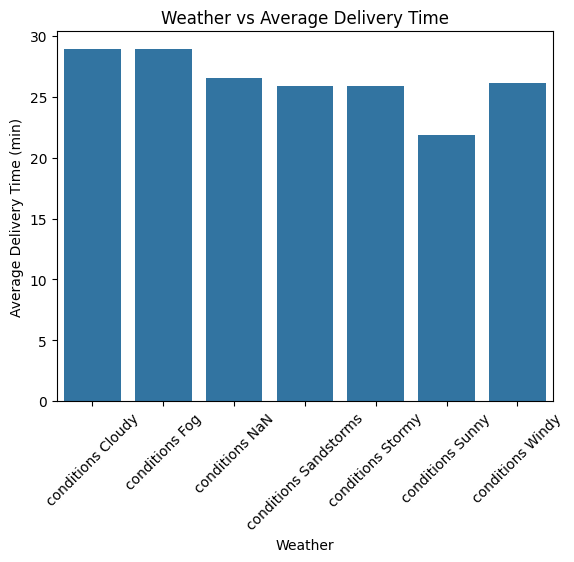

In [74]:
weather_delay = df2.groupby('Weatherconditions')['Time_taken(min)'].mean().reset_index()

sns.barplot(x='Weatherconditions', y='Time_taken(min)', data=weather_delay)
plt.title("Weather vs Average Delivery Time")
plt.ylabel("Average Delivery Time (min)")
plt.xlabel("Weather")
plt.xticks(rotation=45)
plt.show()

In [75]:
print("""Rainy or stormy conditions increase delivery time, confirming that weather is another external factor affecting deliveries.""")

Rainy or stormy conditions increase delivery time, confirming that weather is another external factor affecting deliveries.


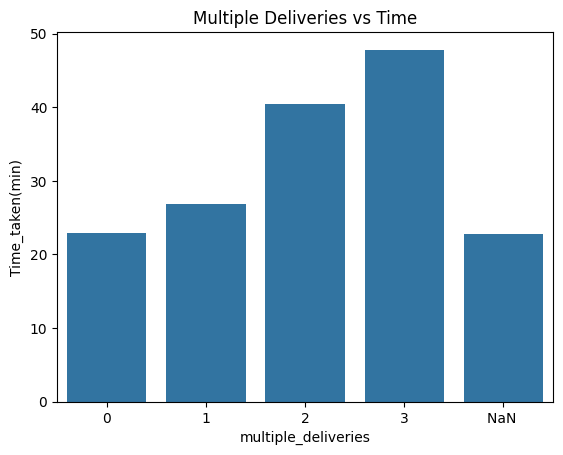

In [76]:
multi_deliveries = df2.groupby('multiple_deliveries')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='multiple_deliveries', y='Time_taken(min)', data=multi_deliveries)
plt.title("Multiple Deliveries vs Time")
plt.show()

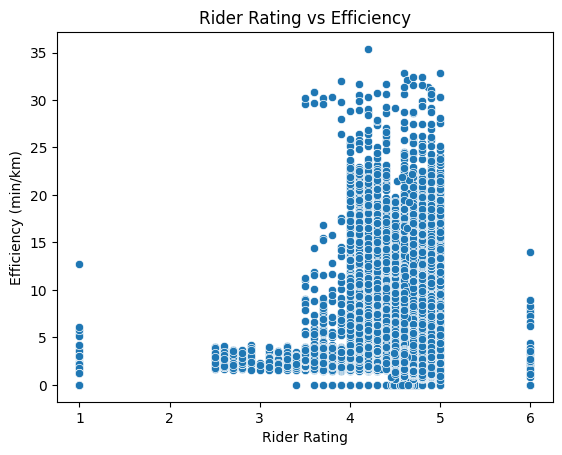

In [77]:
sns.scatterplot(x='Delivery_person_Ratings', y='efficiency', data=df2)
plt.title("Rider Rating vs Efficiency")
plt.xlabel("Rider Rating")
plt.ylabel("Efficiency (min/km)")
plt.show()

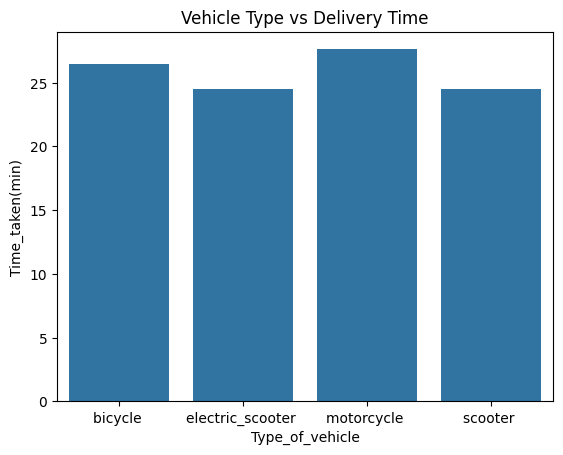

In [78]:
vehicle_delay = df2.groupby('Type_of_vehicle')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='Type_of_vehicle', y='Time_taken(min)', data=vehicle_delay)
plt.title("Vehicle Type vs Delivery Time")
plt.show()

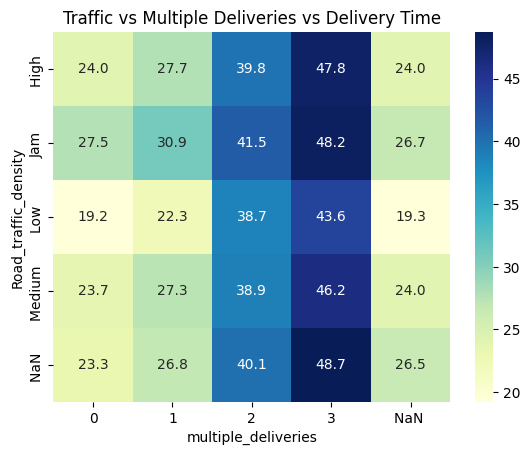

In [79]:
pivot = df2.pivot_table(
    values='Time_taken(min)',
    index='Road_traffic_density',
    columns='multiple_deliveries',
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Traffic vs Multiple Deliveries vs Delivery Time")
plt.show()

In [80]:
print("""External factors dominate system-wide delays: distance, traffic, city, weather.
Internal factors like multiple deliveries, vehicle type, and rider efficiency explain differences among riders.
Operational improvement can reduce delays by optimizing assignments and delivery routing.
Rider ratings are less impactful than efficiency, so focus on training and allocation.""")

External factors dominate system-wide delays: distance, traffic, city, weather.
Internal factors like multiple deliveries, vehicle type, and rider efficiency explain differences among riders.
Operational improvement can reduce delays by optimizing assignments and delivery routing.
Rider ratings are less impactful than efficiency, so focus on training and allocation.


In [81]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          45593 non-null  object        
 3   Delivery_person_Ratings      45593 non-null  float64       
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[ns]
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-nu

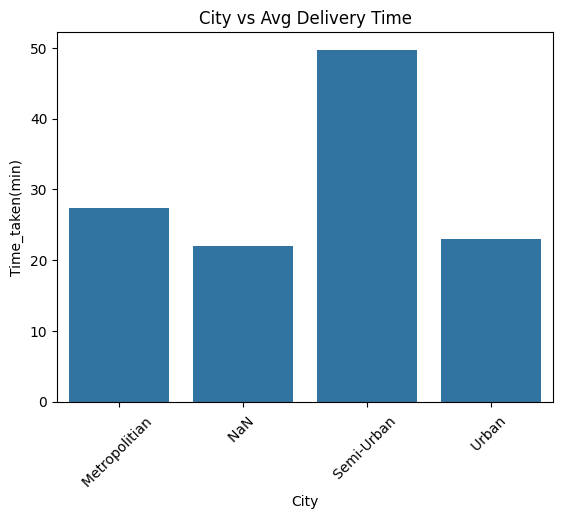

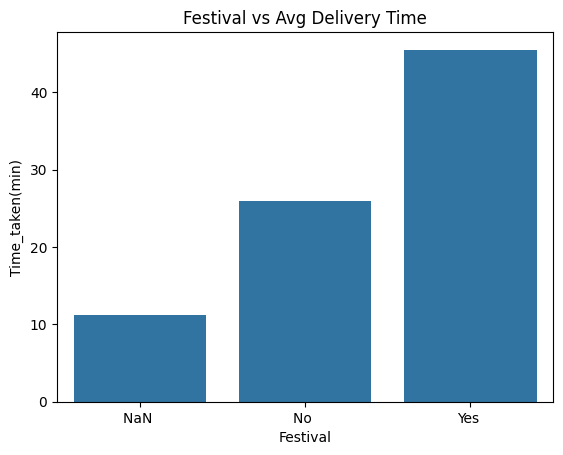

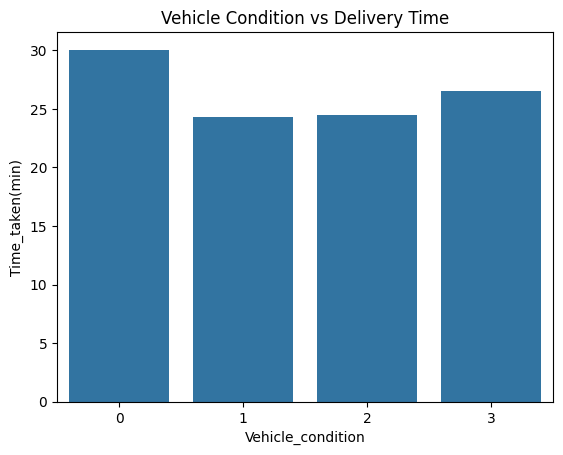

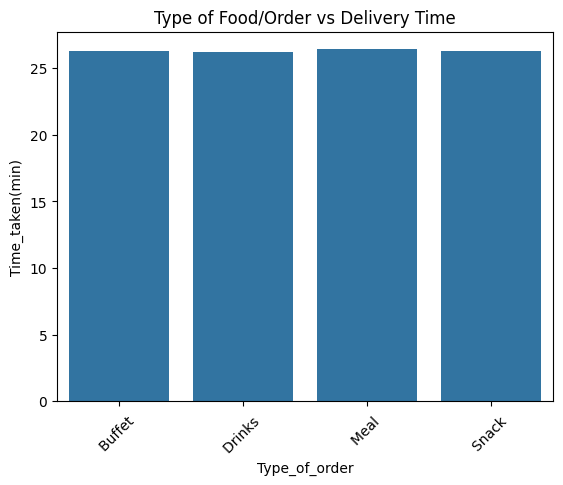

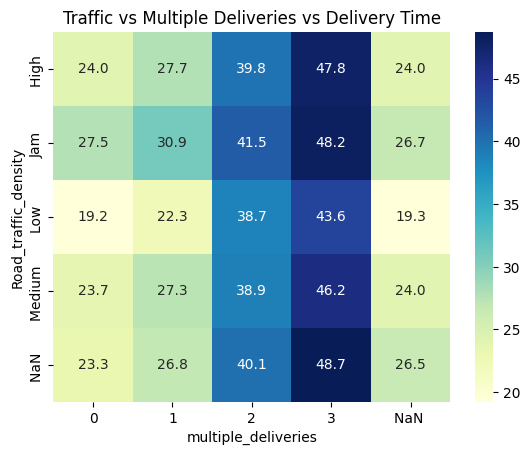

                Factor      Type     Impact
3                 City  External  49.731707
5  Multiple Deliveries  Internal  47.819945
4             Festival  External  45.517857
1              Traffic  External  31.176624
7    Vehicle Condition  Internal  30.072223
2              Weather  External  28.917330
6         Vehicle Type  Internal  27.605674
9        Type of Order  Internal  26.419270
0             Distance  External  -0.002508
8         Rider Rating  Internal  -0.037680
                Factor      Type     Impact
3                 City  External  49.731707
5  Multiple Deliveries  Internal  47.819945
4             Festival  External  45.517857
1              Traffic  External  31.176624
7    Vehicle Condition  Internal  30.072223
2              Weather  External  28.917330
6         Vehicle Type  Internal  27.605674
9        Type of Order  Internal  26.419270
0             Distance  External  -0.002508
8         Rider Rating  Internal  -0.037680


In [82]:

## City vs Time
city_delay = df2.groupby('City')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='City', y='Time_taken(min)', data=city_delay)
plt.title("City vs Avg Delivery Time")
plt.xticks(rotation=45)
plt.show()

## Festival vs Time
festival_delay = df2.groupby('Festival')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='Festival', y='Time_taken(min)', data=festival_delay)
plt.title("Festival vs Avg Delivery Time")
plt.show()

# Step 8: Internal Factor Analysis

## Vehicle Condition
vehicle_cond = df2.groupby('Vehicle_condition')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='Vehicle_condition', y='Time_taken(min)', data=vehicle_cond)
plt.title("Vehicle Condition vs Delivery Time")
plt.show()

## Type of Order
order_type = df2.groupby('Type_of_order')['Time_taken(min)'].mean().reset_index()
sns.barplot(x='Type_of_order', y='Time_taken(min)', data=order_type)
plt.title("Type of Food/Order vs Delivery Time")
plt.xticks(rotation=45)
plt.show()


# Step 9: Combined Analysis (External + Internal)
pivot = df2.pivot_table(
    values='Time_taken(min)',
    index='Road_traffic_density',
    columns='multiple_deliveries',
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Traffic vs Multiple Deliveries vs Delivery Time")
plt.show()

# Step 10: Summary Stats Table

summary_factors = pd.DataFrame({
    'Factor': ['Distance', 'Traffic', 'Weather', 'City', 'Festival', 
               'Multiple Deliveries', 'Vehicle Type', 'Vehicle Condition', 
               'Rider Rating', 'Type of Order'],
    'Type': ['External','External','External','External','External',
             'Internal','Internal','Internal','Internal','Internal'],
    'Impact': [
        df2['distance_km'].corr(df2['Time_taken(min)']),
        df2.groupby('Road_traffic_density')['Time_taken(min)'].mean().max(),
        df2.groupby('Weatherconditions')['Time_taken(min)'].mean().max(),
        df2.groupby('City')['Time_taken(min)'].mean().max(),
        df2.groupby('Festival')['Time_taken(min)'].mean().max(),
        df2.groupby('multiple_deliveries')['Time_taken(min)'].mean().max(),
        df2.groupby('Type_of_vehicle')['Time_taken(min)'].mean().max(),
        df2.groupby('Vehicle_condition')['Time_taken(min)'].mean().max(),
        df2['Delivery_person_Ratings'].corr(df2['efficiency']),
        df2.groupby('Type_of_order')['Time_taken(min)'].mean().max()
    ]
})

print(summary_factors.sort_values(by='Impact', ascending=False))

print(summary_factors.sort_values(by='Impact', ascending=False))

In [83]:
print("===== ALL DATAFRAMES IN MEMORY =====")

for var_name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{var_name} → Shape: {obj.shape}")

===== ALL DATAFRAMES IN MEMORY =====
_ → Shape: (45593, 29)
df1 → Shape: (11399, 2)
df2 → Shape: (45593, 29)
_10 → Shape: (8, 5)
_12 → Shape: (5, 20)
_20 → Shape: (0, 25)
plot_df → Shape: (10, 3)
_25 → Shape: (5, 25)
df → Shape: (4, 3)
_35 → Shape: (5, 27)
rider_perf → Shape: (1320, 12)
_46 → Shape: (1320, 11)
_47 → Shape: (2, 6)
_48 → Shape: (76, 6)
_49 → Shape: (28, 1)
top_riders_based_on_efficiency → Shape: (10, 6)
low_riders_based_on_efficiency → Shape: (10, 6)
low_traffic_df → Shape: (0, 28)
fair_rider_perf → Shape: (0, 2)
top_riders → Shape: (10, 11)
low_riders → Shape: (10, 11)
_60 → Shape: (1320, 12)
_65 → Shape: (3, 3)
_72 → Shape: (45593, 29)
weather_delay → Shape: (7, 2)
multi_deliveries → Shape: (5, 2)
vehicle_delay → Shape: (4, 2)
pivot → Shape: (5, 5)
city_delay → Shape: (4, 2)
festival_delay → Shape: (3, 2)
vehicle_cond → Shape: (4, 2)
order_type → Shape: (4, 2)
summary_factors → Shape: (10, 3)


In [84]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          45593 non-null  object        
 3   Delivery_person_Ratings      45593 non-null  float64       
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[ns]
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-nu

In [85]:
rider_perf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1320 entries, 301 to 69
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rider_ID           1320 non-null   object 
 1   avg_delivery_time  1320 non-null   float64
 2   avg_distance       1320 non-null   float64
 3   avg_efficiency     1320 non-null   float64
 4   avg_rating         1320 non-null   float64
 5   total_orders       1320 non-null   int64  
 6   efficiency_norm    1320 non-null   float64
 7   rating_norm        1320 non-null   float64
 8   orders_norm        1320 non-null   float64
 9   efficiency_score   1320 non-null   float64
 10  rider_score        1320 non-null   float64
 11  category           1320 non-null   object 
dtypes: float64(9), int64(1), object(2)
memory usage: 134.1+ KB


In [86]:
import numpy as np

# Convert to radians
lat1 = np.radians(df2['Restaurant_latitude'].values)
lon1 = np.radians(df2['Restaurant_longitude'].values)
lat2 = np.radians(df2['Delivery_location_latitude'].values)
lon2 = np.radians(df2['Delivery_location_longitude'].values)

# Haversine formula (vectorized, no matrix)
dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df2['distance_km_new'] = 6371 * c  # Earth's radius in km

print(df2['distance_km_new'].describe())

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km_new, dtype: float64


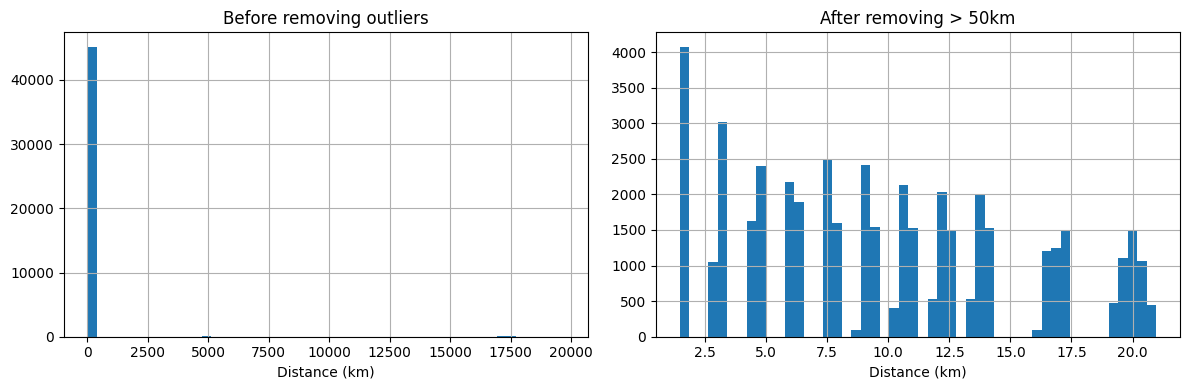

In [87]:
# Visualize the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
df2['distance_km_new'].hist(bins=50)
plt.title('Before removing outliers')
plt.xlabel('Distance (km)')

plt.subplot(1,2,2)
df2[df2['distance_km_new'] <= 50]['distance_km_new'].hist(bins=50)
plt.title('After removing > 50km')
plt.xlabel('Distance (km)')

plt.tight_layout()
plt.show()

In [88]:
# Your data seems Indian, so filter valid India coordinates
df_clean = df2[
    (df2['Restaurant_latitude'].between(6, 37)) &        # India lat range
    (df2['Restaurant_longitude'].between(68, 97)) &      # India lon range
    (df2['Delivery_location_latitude'].between(6, 37)) &
    (df2['Delivery_location_longitude'].between(68, 97))
].copy()

# Recalculate distance on clean coordinates
lat1 = np.radians(df_clean['Restaurant_latitude'].values)
lon1 = np.radians(df_clean['Restaurant_longitude'].values)
lat2 = np.radians(df_clean['Delivery_location_latitude'].values)
lon2 = np.radians(df_clean['Delivery_location_longitude'].values)

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
df_clean['distance_km_new'] = 6371 * c

print(f"Removed: {len(df2) - len(df_clean)} rows")
print(df_clean['distance_km_new'].describe())

Removed: 4071 rows
count    41522.000000
mean         9.720129
std          5.603027
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km_new, dtype: float64


In [89]:
df2['distance_km'].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64

In [90]:
# Food delivery is rarely > 50 km
df_clean = df2[df2['distance_km_new'] <= 50].copy()
print(f"Removed: {len(df2) - len(df_clean)} rows ({(len(df2)-len(df_clean))/len(df2)*100:.2f}%)")

Removed: 431 rows (0.95%)


In [91]:
df_clean

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time,Delivery time,distance_km,efficiency,delay_flag,distance_km_new
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,...,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,False,False,9.0,3.025149,7.933493,on_time,3.025149
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,...,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,False,False,28.0,20.183530,1.634996,delay,20.183530
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,...,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,False,False,11.0,1.552758,16.744401,on_time,1.552758
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,...,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,False,False,11.0,7.790401,2.695625,on_time,7.790401
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,...,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,False,False,15.0,6.210138,4.830811,on_time,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,...,2022-03-24 11:35:00,2022-03-24 11:45:00,10.0,False,False,22.0,1.489846,21.478732,delay,1.489846
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,...,2022-02-16 19:55:00,2022-02-16 20:10:00,15.0,False,False,21.0,11.007735,3.270428,delay,11.007735
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,...,2022-03-11 23:50:00,2022-03-12 00:05:00,15.0,False,False,1.0,4.657195,3.435544,on_time,4.657195
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,...,2022-03-07 13:35:00,2022-03-07 13:40:00,5.0,False,False,21.0,6.232393,4.171752,on_time,6.232393


In [92]:
df2['distance_km'].tail(50)

45543     9.435202
45544     2.976549
45545     9.087973
45546    14.022137
45547     3.145067
45548     6.209485
45549     9.348069
45550     1.512556
45551     4.657347
45552    12.074056
45553     6.128501
45554     3.116204
45555     1.554509
45556     9.348326
45557    12.240858
45558    10.725035
45559    12.419650
45560     3.108926
45561     8.940168
45562    19.088943
45563     7.562109
45564    13.767319
45565     1.509231
45566     3.040555
45567    12.117044
45568    17.097074
45569    11.007735
45570     3.052741
45571    13.829770
45572    13.972124
45573    12.237379
45574     4.589345
45575     9.220582
45576    20.442930
45577    14.152801
45578     3.116127
45579     7.862668
45580     3.109134
45581     4.560738
45582     3.064267
45583    20.206808
45584     3.104827
45585    10.445325
45586     4.657133
45587    16.600272
45588     1.489846
45589    11.007735
45590     4.657195
45591     6.232393
45592    12.074396
Name: distance_km, dtype: float64

In [93]:
# See how many rows have bad distances
print("Rows > 50km  :", (df2['distance_km'] > 50).sum())
print("Rows <= 50km :", (df2['distance_km'] <= 50).sum())

Rows > 50km  : 431
Rows <= 50km : 45162


In [94]:
df2 = df2.drop(columns=['distance_km_new'])

In [95]:
df2

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Time_taken(min),Order_Time_Full,Pickup_Time_Full,order_to_pickup_time,missing_order_time,missing_pickup_time,Delivery time,distance_km,efficiency,delay_flag
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,...,24,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,False,False,9.0,3.025149,7.933493,on_time
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,...,33,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,False,False,28.0,20.183530,1.634996,delay
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,...,26,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,False,False,11.0,1.552758,16.744401,on_time
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,...,21,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,False,False,11.0,7.790401,2.695625,on_time
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,...,30,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,False,False,15.0,6.210138,4.830811,on_time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,...,32,2022-03-24 11:35:00,2022-03-24 11:45:00,10.0,False,False,22.0,1.489846,21.478732,delay
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,...,36,2022-02-16 19:55:00,2022-02-16 20:10:00,15.0,False,False,21.0,11.007735,3.270428,delay
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,...,16,2022-03-11 23:50:00,2022-03-12 00:05:00,15.0,False,False,1.0,4.657195,3.435544,on_time
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,...,26,2022-03-07 13:35:00,2022-03-07 13:40:00,5.0,False,False,21.0,6.232393,4.171752,on_time


In [96]:
df

,Traffic,Delivery_Time,% Increase vs Low
0,Low,11.27,0.00
1,Medium,16.71,48.27
2,High,17.26,53.15
3,Jam,21.17,87.84


In [97]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          45593 non-null  object        
 3   Delivery_person_Ratings      45593 non-null  float64       
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[ns]
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-nu

In [98]:
df2['year_month'] = df2['Order_Date'].dt.to_period('M')

In [99]:
orders_per_month = df2.groupby('year_month')['ID'].nunique().reset_index()
orders_per_month.columns = ['Month', 'Order_Count']

In [100]:
orders_per_month

,Month,Order_Count
0,2022-02,7242
1,2022-03,31989
2,2022-04,6362


In [101]:
rider_perf['category'].value_counts()

category
Average           1059
Low Performer      172
High Performer      89
Name: count, dtype: int64

In [102]:
rider_perf

,Rider_ID,avg_delivery_time,avg_distance,avg_efficiency,avg_rating,total_orders,efficiency_norm,rating_norm,orders_norm,efficiency_score,rider_score,category
301,CHENRES010DEL02,25.258621,320.126392,2.811788,4.710909,58,0.133901,0.684848,0.854839,0.866099,0.809472,High Performer
625,INDORES08DEL02,24.676923,10.540820,3.338981,4.718750,65,0.202454,0.697917,0.967742,0.797546,0.801696,High Performer
1285,VADRES08DEL02,25.075758,11.245996,3.188643,4.679365,66,0.182905,0.632275,0.983871,0.817095,0.795004,High Performer
383,COIMBRES07DEL03,21.883721,9.675095,2.721311,4.762500,43,0.122136,0.770833,0.612903,0.877864,0.792763,High Performer
713,JAPRES18DEL03,24.773585,11.831761,2.796205,4.706122,53,0.131874,0.676871,0.774194,0.868126,0.791963,High Performer
...,...,...,...,...,...,...,...,...,...,...,...,...
93,ALHRES12DEL01,35.000000,8.238896,8.381274,4.625000,12,0.858129,0.541667,0.112903,0.141871,0.256016,Low Performer
777,KNPRES20DEL01,29.642857,8.952874,6.159665,4.307143,14,0.569242,0.011905,0.145161,0.430758,0.247983,Low Performer
48,AGRRES17DEL01,33.666667,7.812717,9.472293,4.741667,12,1.000000,0.736111,0.112903,0.000000,0.243414,Low Performer
927,LUDHRES09DEL01,26.000000,6.511331,8.173934,4.522222,9,0.831168,0.370370,0.064516,0.168832,0.208430,Low Performer


In [103]:
rider_perf.sort_values(by='rider_score', ascending=False

_IncompleteInputError: incomplete input (924223516.py, line 1)

In [ ]:
rider_perf.head(20)